# Final Exam (Part 2)
**Instructions:** <br>
a. this is exam part2. For part1, please go to the Canvas quiz and finish accordingly.  <br>
b. write your answer after `# your answer here`. Do not delete any code that is in the cell, as the code facilitates checking your answers. If you happen to delete any code that prevents expected outputs, you may lose points. <br>
c. make sure the plot shows all the necessary information, including but not limited to **title, axis labels with units, legend**, etc. <br>
d. when you finish the tasks, make sure to use `Kernel` -> `Restart and Run All` to restart the kernel and rerun the entire notebook to generate desired outputs, before submitting your assignment. <br>
e. upload your .ipynb file. <br>

### `SAVE your work and double-check that you upload the correct version with answers before you leave!`

Each subquestion in Question 1, 2, and 3 is worth 5 points. Q1: 10 points; Q2: 20 points; Q3: 20 points; Q4: 10 points. The total score is 60 points.

### Question 1

**1. (1):**
For an input of a list of strings, count the total number of elements whose string length is 3 or more and the first and last character are the same. <br> <br>
Sample List : ['adc', 'xdz', 'ada', '2022'] <br>
Expected Result : 2

In [ ]:
# your answer here
def count_strings(words):
  count = 0
  for i in words:
    if (len(i)>=3) and (i[0]==i[-1]):
      count +=1
  return count


#for grading
print(count_strings(['adc', 'xdz', 'ada', '2022']))
print(count_strings(['aa', 'acc', 'xex', '1991']))

2
2


**1. (2):**
Use lambda to remove None values from the input list. <br> <br>
Sample input: <br>
[9, None, 12, None, -56, None, 2022, 12, 9] <br>
Sample output:<br>
[9, 12, -56, 2022, 12, 9]<br>

In [ ]:
# your answer here
def remove_none_values(number):
  return list(filter(lambda x:x !=None,number))

#for grading
nums = [9, None, 12, None, -56, None, 2022, 12, 9]
print("Original list:")
print(nums)
print("\nRemove None value from the said list:")
print(remove_none_values(nums))

Original list:
[9, None, 12, None, -56, None, 2022, 12, 9]

Remove None value from the said list:
[9, 12, -56, 2022, 12, 9]


### Question 2

The taxis dataset is a public trip record data collected on an open platform. The yellow and green taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

In [1]:
# Question 2
import pandas as pd
import seaborn as sns
import numpy as np
taxi = sns.load_dataset('taxis')
taxi.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


**2.(1)** How many trip records are there in total?

In [ ]:
# Your answer here
taxi.shape[0]


6433

**2.(2)** Convert "pickup" and "dropoff" columns into the datetime type. Further, compute the difference between 'dropoff' and 'pickup' and add a new colunm "diff_time".

In [ ]:
# Your answer here
taxi['pickup'] = pd.to_datetime(taxi['pickup'])
taxi['dropoff'] = pd.to_datetime(taxi['dropoff'])
taxi['diff_time']=taxi['dropoff']-taxi['pickup']

#for grading
print(taxi[['pickup','dropoff']].dtypes)
taxi['diff_time'].head()

pickup     datetime64[ns]
dropoff    datetime64[ns]
dtype: object


,diff_time
0,0 days 00:06:15
1,0 days 00:07:05
2,0 days 00:07:24
3,0 days 00:25:52
4,0 days 00:09:32


**2.(3)** Which payment method is more popular in the taxi dataset?

In [ ]:
# Your answer here： one line of code
taxi['payment'].value_counts().iloc[0]

4577

**2.(4)** What is the average `tip` for trips that picked up in the `Manhattan` area paid by `cash`? What is the average `tip` for trips that picked up in the `Manhattan` area and were paid in `credit card`?

The result should be well formatted using string formatting, and it should print as:

The average tip for trips that picked up in the Manhattan area paid by cash is XX

The average tip for trips that picked up in the Manhattan area paid by credit card is XX

In [ ]:
# Your answer here
taxi_cash = taxi[(taxi["payment"]=='cash') & (taxi["pickup_borough"]=="Manhattan")]
taxi_cc = taxi[(taxi["payment"]=='credit card') & (taxi["pickup_borough"]=="Manhattan")]
print(f"The average tip for trips that picked up in the Manhattan area paid by cash is {taxi_cash['tip'].mean():.2f}")
print(f"The average tip for trips that picked up in the Manhattan area paid by credit card is {taxi_cc['tip'].mean():.2f}")


The average tip for trips that picked up in the Manhattan area paid by cash is 0.00
The average tip for trips that picked up in the Manhattan area paid by credit card is 2.66


### Question 3
Continue to use the `taxi` dataset. <br>
**3. (1):** Create `taxi_multi` from taxi, by (a) dropping observations that have NA values in `pickup_borough` and `dropoff_borough`; (b) building the MultiIndex from columns `pickup_borough` and `dropoff_borough`, and sorting the indexes; (c) keeping the first ten columns from `pickup` to `payment` only and dropping the rest columns.

In [ ]:
# your answer here
taxi_multi = taxi.dropna(subset=["pickup_borough","dropoff_borough"])
taxi_multi = taxi_multi.set_index(["pickup_borough","dropoff_borough"]).sort_index()
taxi_multi = taxi_multi.loc[:,"pickup":"payment"]

#for grading
print(taxi_multi.shape)
taxi_multi.head()

(6383, 10)


pickup             dropoff  \
pickup_borough dropoff_borough                                           
Bronx          Bronx           2019-03-04 20:56:26 2019-03-04 21:13:36   
               Bronx           2019-03-01 18:02:02 2019-03-01 18:43:57   
               Bronx           2019-03-25 18:15:35 2019-03-25 18:16:08   
               Bronx           2019-03-04 13:59:55 2019-03-04 14:08:23   
               Bronx           2019-03-01 16:09:27 2019-03-01 16:48:09   

                                passengers  distance  fare  tip  tolls  total  \
pickup_borough dropoff_borough                                                  
Bronx          Bronx                     1      9.97  28.5  0.0    0.0   29.8   
               Bronx                     1      4.89  26.0  0.0    0.0   27.8   
               Bronx                     2      0.07   2.5  0.0    0.0    4.3   
               Bronx                     3      1.60   8.5  0.0    0.0    9.3   
               Bronx                     1      4.70  24.5  0.0    0.0   26.3   

                                 color      payment  
pickup_borough dropoff_borough                       
Bronx          Bronx            yellow  credit card  
               Bronx            yellow  credit card  
               Bronx            yellow  credit card  
               Bronx            yellow         cash  
               Bronx            yellow  credit card

**3. (2)**: Using `taxi_multi`, calculate the total trip `distance` made in Bronx, with pickup and dropoff both in Bronx.

In [ ]:
print('Total trip distance in Bronx = ')
# your answer here: one line of code
taxi_multi[(taxi_multi.index.get_level_values("pickup_borough")=="Bronx")&(taxi_multi.index.get_level_values("dropoff_borough")=="Bronx")]['distance'].sum()

Total trip distance in Bronx = 


242.70000000000002

**3. (3)**: Using `taxi_multi`, calculate the total trip `distance` by each `dropoff_borough`.

In [ ]:
# your answer here: one line of code
taxi_multi.groupby("dropoff_borough")["distance"].sum()

,distance
dropoff_borough,
Bronx,905.88
Brooklyn,2519.28
Manhattan,12426.76
Queens,3230.13
Staten Island,31.71


**3. (4)**: Use the pivot_table method to find the sum of the `fare` by `pickup_borough` (row) and by `dropoff_borough` (column). Output: A dataframe is expected with index as `pickup_borough` and columns as `dropoff_borough`. For certain combinations of `pickup_borough` and `dropoff_borough`, there are no observations, and thus the values will be "NA".

In [ ]:
taxi.pivot_table?

In [ ]:
# your answer here: one line of code
taxi.pivot_table(values="fare",index="pickup_borough",columns="dropoff_borough",fill_value="NA",aggfunc='sum')


<ipython-input-44-182f06dbd84e>:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  taxi.pivot_table(values="fare",index="pickup_borough",columns="dropoff_borough",fill_value="NA",aggfunc='sum')


dropoff_borough,Bronx,Brooklyn,Manhattan,Queens,Staten Island
pickup_borough,,,,,
Bronx,959.58,216.25,742.45,160.63,NA
Brooklyn,290.62,3349.48,1681.47,905.91,NA
Manhattan,1327.00,3747.75,47516.49,5643.68,89.0
Queens,503.50,2295.17,8270.94,4471.45,NA


### Question 4

Continue to use the dataset `taxi`. Count the number of trips by the pickup zone, based on Manhattan pickup trips only. Draw a bar plot for the pickup zones that have more than 180 trips.

<BarContainer object of 7 artists>

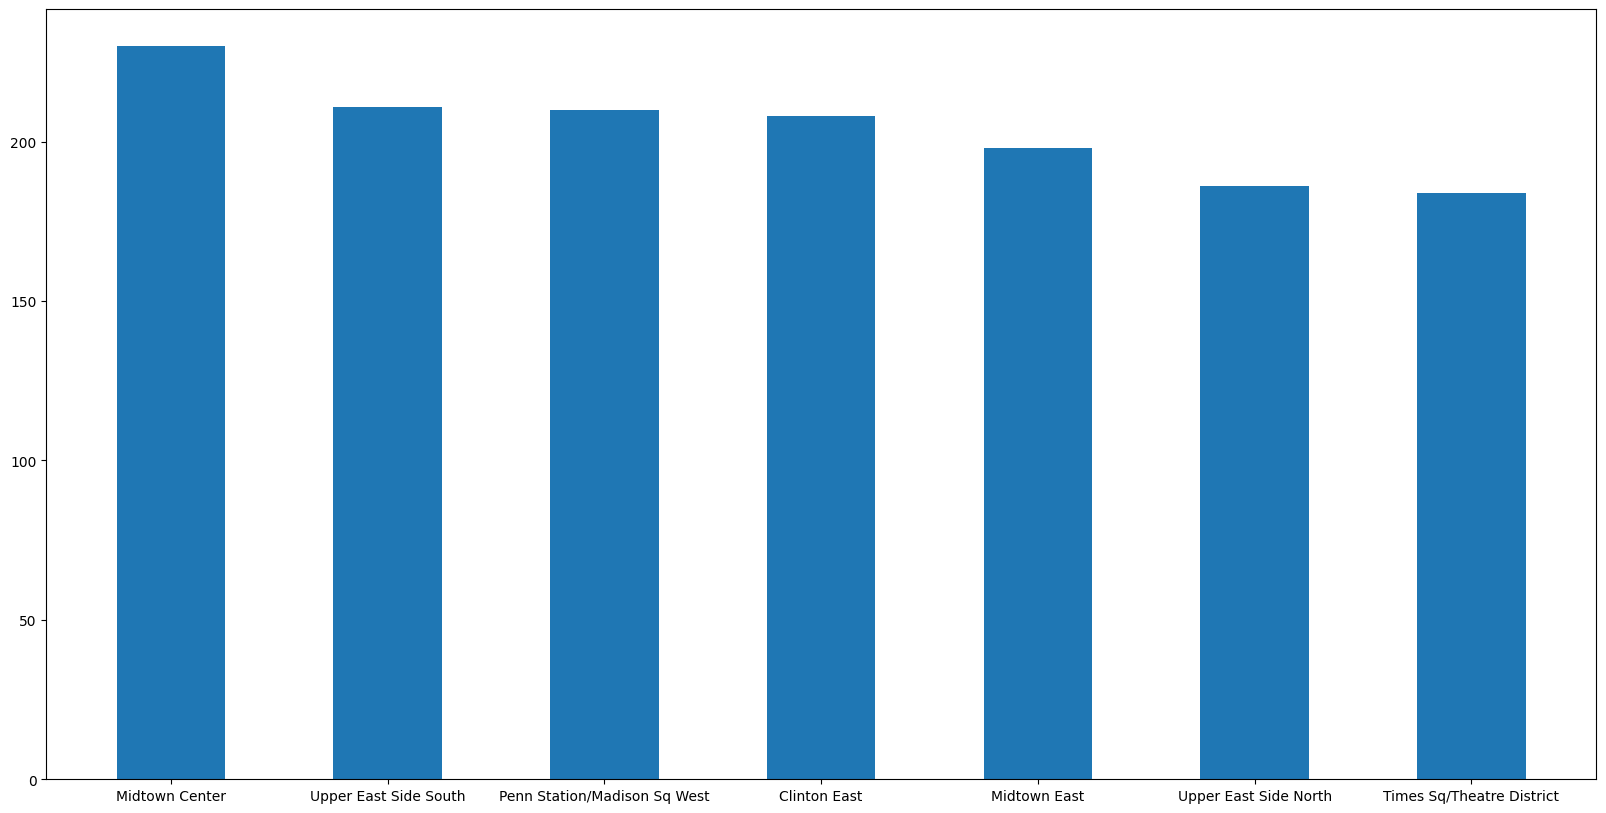

In [ ]:
# Your answer here
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20,10))
df4 = taxi[taxi["pickup_borough"]=="Manhattan"]
pickup_counts = df4['pickup_zone'].value_counts()
pickup_counts_f = pickup_counts[pickup_counts > 180]
plt.bar(pickup_counts_f.index,pickup_counts_f.values,width=0.5)














